- 从**概率分布（Probability Distribution）**的角度来看（都是在训练 $\pi_{ref}$ 到一个新的分布），LLM 的 SFT（Supervised Fine-Tuning）和 RL（Reinforcement Learning，如 RLHF）完全是两种不同的数学过程。
    - SFT 是在“模仿”人类分布的平均形态（$<\text{prompt}, \text{response}>$），而 RL 是在“坍缩”到分布中奖励最高的那个尖峰 （$<\text{prompt}, r(\text{prompt},\text{rollout response})>$）。
    - RL自带隐式的kl散度，因为其产生的数据是模型产生的，数据分布符合模型规律，而sft的数据跟模型完全无关，所以训练过程很容易造成遗忘
- https://gemini.google.com/app/c298bdec64527054

In [13]:
from IPython.display import Image
Image(url='./imgs/rl-loss-dpo1.png', width=600)

- 在标准强化学习中，“回报”通常指累计折扣奖励（Cumulative Discounted Reward）。但在 RL4LLM 的语境下（rlhf, rlvr, rft, 把 llm 当做 policy $\pi_\theta$）（通常被建模为 Contextual Bandit 问题或单步决策），整个生成的句子 $y$ (response)被视为一个动作，奖励在句子生成结束后一次性给出。在这种情况下，奖励（Reward）在数值上等同于回报（Return）。但在术语描述上，论文和业界通常称其为“最大化期望奖励”。
- PPO4LLM 
    - $r_t(s_t, a_t) = \underbrace{r_{\text{score}}(x, y)}_{\text{仅在最后一步非零}} - \underbrace{\beta \log \frac{\pi_\theta(a_t|s_t)}{\pi_{\text{ref}}(a_t|s_t)}}_{\text{每一步都有}}$
    - $r_t = \begin{cases}
-\beta \log \frac{\pi_\theta(y_t|s_t)}{\pi_{\text{ref}}(y_t|s_t)} & \text{if } t < T \quad (\text{中间步：只有KL惩罚}) \\
R_{\phi}(x, y) - \beta \log \frac{\pi_\theta(y_T|s_T)}{\pi_{\text{ref}}(y_T|s_T)} & \text{if } t = T \quad (\text{最后一步：RM打分 + KL惩罚})
\end{cases}$
    - $G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k}=\underbrace{R_{\phi}(x, y)}_{\text{最终得分}} + \sum_{k=0}^{T-t} \left( -\beta \log \frac{\pi_\theta(y_{t+k}|s_{t+k})}{\pi_{\text{ref}}(y_{t+k}|s_{t+k})} \right)$
        - 在 LLM 场景下，通常设置折扣因子 $\gamma = 1$（或者非常接近 1），这意味着我们认为生成的每一个 token 对最终结果的贡献是等价的，没有时间上的贬值。

### 分布的视角 (a probabilistic perspective)

> p, q 的讨论，p 是 target 分布，q 是待 learned 的一个分布

- SFT: $\mathcal{L}_{SFT}(\theta) = \mathbb{E}_{x \sim P_{data}} [\log P_{\theta}(x)]$

$$
\begin{aligned}
D_{KL}(P_{data} \| P_{\theta}) &= \mathbb{E}_{x \sim P_{data}} [\log P_{data}(x) - \log P_{\theta}(x)] \\
&= \underbrace{\mathbb{E}_{x \sim P_{data}} [\log P_{data}(x)]}_{\text{数据熵 (常数)}} - \underbrace{\mathbb{E}_{x \sim P_{data}} [\log P_{\theta}(x)]}_{\text{SFT 目标函数}}
\end{aligned}
$$

- SFT (Forward KL): $D_{KL}(P_{data} || P_{model})$
    - SFT 使用最大似然估计（MLE）。它的目的是让模型分布 $P_{model}$ 尽可能“宽”，去覆盖掉 $P_{data}$（人类数据）出现过的所有地方。
    - 结果： 模型会保留人类的多样性，包括人类的口癖、不同的措辞方式，甚至是一些平庸的回答，只要它们在训练集里出现过。
    - SFT 的分布形态：平缓且宽 (Platykurtic / Wide)
    - SFT 的致幻：长尾分布的拟合不足
        - SFT 被迫去拟合训练数据的全部分布，包括那些它没见过的长尾知识（Long-tail knowledge）。
        - 当模型试图去“覆盖”它并未真正理解的数据点时，它学会的是形式而非实质。它在分布的低密度区域（它不熟悉的知识）强行分配了概率，导致一本正经地胡说八道。

$$
J(\theta) = \mathbb{E}_{x \sim P_{\theta}} [R(x)] - \beta D_{KL}(P_{\theta} \| P_{ref})
$$

- 理论上的“最优分布” $P^*$，它由能量模型定义（Gibbs 分布）：$P^*(x) = \frac{1}{Z} P_{ref}(x) e^{\frac{R(x)}{\beta}}$
    - DPO 推导

$$
\begin{aligned}
D_{KL}(P_{\theta} \| P^*) &= \mathbb{E}_{x \sim P_{\theta}} [\log P_{\theta}(x) - \log P^*(x)] \\
&= \mathbb{E}_{x \sim P_{\theta}} \left[ \log P_{\theta}(x) - \log \left( \frac{1}{Z} P_{ref}(x) e^{\frac{R(x)}{\beta}} \right) \right] \\
&= \mathbb{E}_{x \sim P_{\theta}} \left[ \log P_{\theta}(x) - \log P_{ref}(x) - \frac{R(x)}{\beta} + \log Z \right] \\
&= \underbrace{\mathbb{E}_{x \sim P_{\theta}} \left[ \log \frac{P_{\theta}(x)}{P_{ref}(x)} \right]}_{D_{KL}(P_{\theta} \| P_{ref})} - \frac{1}{\beta} \underbrace{\mathbb{E}_{x \sim P_{\theta}} [R(x)]}_{\text{期望奖励}} + \log Z
\end{aligned}
$$

- $D_{KL}(P_{\theta} \| P^*) = -\frac{1}{\beta} \left( \mathbb{E}_{x \sim P_{\theta}} [R(x)] - \beta D_{KL}(P_{\theta} \| P_{ref}) \right) + \text{const}$
    - 最大化 RL 的目标函数 $J(\theta)$ 等价于最小化 Reverse KL $D_{KL}(P_{\theta} \| P^*)$。
    - 直观意义 (Mode Seeking)：
        - Reverse KL 的期望是基于模型自身 $P_{\theta}$ 计算的。
        - 为了最小化 $\int P_{\theta}(x) \log \frac{P_{\theta}(x)}{P^*(x)} dx$，模型倾向于将概率质量集中在 $P^*(x)$ 最大的区域（即奖励高的地方）。
        - 如果 $P^*(x)$ 很小（奖励低），模型只需让 $P_{\theta}(x) \rightarrow 0$ 即可使该项为 0。
        - 这导致模型可以忽略那些奖励低或一般的区域，哪怕那些区域在 $P_{data}$ 中存在。模型会坍缩到奖励最高的单一模式上。
- RL (Reverse KL): $D_{KL}(P_{model} || P_{target\_reward})$
    - 分布变窄，熵（Entropy）降低。模型变得“固执”且单一，但在这个单一方向上表现极佳。
    - RL 的分布形态：尖锐且窄 (Leptokurtic / Narrow)
    - RL 的致幻：奖励黑客 (Reward Hacking) / 偏好过拟合
        - RL 模型为了最大化奖励，会主动扭曲原本的知识分布。
        - 如果 Reward Model 倾向于“更长、更自信、更有逻辑连接词”的回答，RL 会将分布强行推向这些特征，哪怕事实是错误的。这是一种主动的分布偏移，为了迎合判卷人（Reward Model）而牺牲了真实性（Ground Truth）。
    - the objective is to maximize the expected return, leading to a focused, low-variance policy that targets high-certainty outcomes.

### examples

- 经典的变分近似 (Variational Approximation) 问题：使用一个单峰高斯分布 $Q_\theta(x)$ 去拟合一个复杂的双峰混合高斯分布 $P(x)$。
    - The Target/Teacher (GMM)： $P(x) = w_1 \cdot \mathcal{N}(x; \mu_1, \sigma_{tgt}^2) + w_2 \cdot \mathcal{N}(x; \mu_2, \sigma_{tgt}^2)$
        - 权重 (不对称): $w_1 = 0.3, \quad w_2 = 0.7$
        - 均值: $\mu_1 = -2.0, \quad \mu_2 = +2.0$
        - 标准差: $\sigma_{tgt} = 0.5$
    - The model/student: $Q_\theta(x) = \mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
- 优化目标以及蒙特卡洛模拟
    - SFT (Forward KL)：
        - $\theta^*_{SFT} = \arg\min_{\theta} D_{KL}(P \| Q_\theta) = \arg\min_{\theta} \mathbb{E}_{x \sim P} \left[ \log \frac{P(x)}{Q_\theta(x)} \right]$
        - 忽略常数项（数据的熵），这等价于最大化对数似然 (MLE)：$\mathcal{L}_{SFT}(\theta) = \mathbb{E}_{x \sim P} [ -\log Q_\theta(x) ]$
    - SFT 蒙特卡洛模拟
        - 从 $P(x)$ 采样来近似期望：
            - 采样: $x_i \sim P(x)$ (对应 `target.sample()`)
            - 损失函数: $L \approx -\frac{1}{N} \sum_{i=1}^N \log Q_\theta(x_i)$（`-model.log_prob(x_data).mean()`）
    - RL 旨在最小化从模型分布 $Q$ 到目标分布 $P$ 的 KL 散度（Reverse KL）：
        - $\theta^*_{RL} = \arg\min_{\theta} D_{KL}(Q_\theta \| P) = \arg\min_{\theta} \mathbb{E}_{x \sim Q_\theta} \left[ \log \frac{Q_\theta(x)}{P(x)} \right]$
            - 展开：$\mathcal{L}_{RL}(\theta) = \mathbb{E}_{x \sim Q_\theta} [ \underbrace{\log Q_\theta(x)}_{\text{负熵}} - \underbrace{\log P(x)}_{\text{奖励 (Reward)}} ]$
                - $\mathbb{E}_{x \sim Q_\theta}[\log Q_\theta(x)] = - H(Q_\theta)$, $\min \mathcal{L} \Rightarrow \min (-H(Q)) \Rightarrow \max H(Q)$
                    -  RL 中的 探索（Exploration） 机制。模型希望分布 $Q_\theta$ 尽可能宽（随机），以防止过早收敛到局部最优解。
                -  $\log P(x)$ —— “奖励” (Reward) （$P(x) = \frac{1}{Z} \exp\left(\frac{R(x)}{\alpha}\right)$）
        - 脚本通过从 $Q_\theta(x)$ 自身采样，并利用重参数化技巧 (Reparameterization Trick) 来保留梯度：
            - 采样: $x_i = \mu + \sigma \cdot \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0,1)$ (对应 `model.rsample()`)
            - $L \approx \frac{1}{N} \sum_{i=1}^N (\log Q_\theta(x_i) - \log P(x_i))$（(对应 `(log_q_model - log_p_target).mean())`）

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [8]:
class TargetDistribution:
    """
    目标分布 (P_data): 一个双峰高斯混合分布 (Bimodal Gaussian Mixture)
    模拟真实世界数据的多样性，或者一个有两个高回报区域的奖励函数。
    """
    def __init__(self):
        # 两个峰：一个在 -2.0，一个在 +2.0
        self.means = torch.tensor([-2.0, 2.0])
        # 我们可以让右边的峰稍微高一点点 (模拟更好的奖励)
        self.weights = torch.tensor([0.3, 0.7]) 
        self.std = 0.5

    def log_prob(self, x):
        """计算目标分布的 log probability (未归一化的 log_prob 也可以作为 Reward)"""
        # 计算每个分量的概率密度
        # exp(-0.5 * ((x - mu)/sigma)^2) / (sigma * sqrt(2pi))
        c = 1.0 / (self.std * np.sqrt(2 * np.pi))
        
        prob_1 = c * torch.exp(-0.5 * ((x - self.means[0]) / self.std) ** 2)
        prob_2 = c * torch.exp(-0.5 * ((x - self.means[1]) / self.std) ** 2)
        
        # 混合概率
        prob = self.weights[0] * prob_1 + self.weights[1] * prob_2
        return torch.log(prob + 1e-8)

    def sample(self, batch_size):
        """从真实分布中采样 (模拟获取人类SFT数据)"""
        # 随机选择从哪个峰采样
        indices = torch.multinomial(self.weights, batch_size, replacement=True)
        chosen_means = self.means[indices]
        # 采样
        return torch.normal(chosen_means, self.std)

In [4]:
class GaussianModel(nn.Module):
    """
    模型分布 (Q_theta): 单高斯分布 (Single Gaussian)
    模拟能力有限的模型，它必须在 '覆盖所有数据' 和 '寻找最佳模式' 之间做选择。
    """
    def __init__(self):
        super().__init__()
        # 初始化均值和标准差 (可学习参数)
        self.mu = nn.Parameter(torch.tensor(0.0))
        self.log_sigma = nn.Parameter(torch.tensor(0.0)) # 使用 log_sigma 保证 sigma > 0

    def get_dist(self):
        sigma = torch.exp(self.log_sigma)
        return torch.distributions.Normal(self.mu, sigma)

    def log_prob(self, x):
        return self.get_dist().log_prob(x)

    def rsample(self, batch_size):
        """重参数化采样 (Reparameterization Trick) - 允许梯度反向传播"""
        return self.get_dist().rsample((batch_size,))

In [5]:
def train_model(objective_type, steps=1000, lr=0.01):
    target = TargetDistribution()
    model = GaussianModel()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = []

    for step in range(steps):
        optimizer.zero_grad()
        
        if objective_type == 'SFT_Forward_KL':
            # === SFT (Supervised Fine-Tuning) ===
            # 目标：最小化 Forward KL (P || Q) => 最大化 Likelihood
            # 1. 从数据分布 P 中采样 (模拟读取数据集)
            x_data = target.sample(1024)
            
            # 2. 最大化这些数据在模型 Q 下的对数概率 (NLL Loss)
            # Loss = - E_x~P [ log Q(x) ]
            loss = -model.log_prob(x_data).mean()

        elif objective_type == 'RL_Reverse_KL':
            # === RL (Reinforcement Learning) ===
            # 目标：最小化 Reverse KL (Q || P) => E_x~Q [ log Q(x) - log P(x) ]
            # 等价于最大化: E_x~Q [ Reward(x) - log Q(x) ] (熵正则化 RL)
            
            # 1. 从模型 Q 自身采样 (模型生成回答)
            # 必须使用 rsample 保持梯度流
            x_model = model.rsample(1024)
            
            # 2. 计算 Reward (这里 Reward = log P(x))
            log_p_target = target.log_prob(x_model)
            log_q_model = model.log_prob(x_model)
            
            # 3. Reverse KL Loss = log Q(x) - log P(x)
            loss = (log_q_model - log_p_target).mean()
        
        loss.backward()
        optimizer.step()
        
        if step % 10 == 0:
            history.append((model.mu.item(), torch.exp(model.log_sigma).item()))

    return model, history

In [10]:
def visualize_results():
    print("正在训练 SFT 模型 (Forward KL)...")
    model_sft, hist_sft = train_model('SFT_Forward_KL')
    
    print("正在训练 RL 模型 (Reverse KL)...")
    model_rl, hist_rl = train_model('RL_Reverse_KL')

    # 绘图准备
    x = torch.linspace(-6, 6, 1000)
    target = TargetDistribution()
    target_log_prob = target.log_prob(x)
    target_prob = torch.exp(target_log_prob)

    # 计算最终模型的分布
    with torch.no_grad():
        sft_prob = torch.exp(model_sft.log_prob(x))
        rl_prob = torch.exp(model_rl.log_prob(x))

    plt.figure(figsize=(14, 6))
    
    # --- 左图：SFT 结果 ---
    plt.subplot(1, 2, 1)
    plt.title("SFT Objective (Forward KL)\nResult: Mode Covering (Mean Seeking)", fontsize=14)
    plt.plot(x, target_prob, 'g--', label='Target P(x) (Bimodal)', linewidth=2, alpha=0.6)
    plt.plot(x, sft_prob, 'b-', label='Model Q(x) (SFT)', linewidth=3)
    plt.fill_between(x, sft_prob, alpha=0.2, color='blue')
    plt.text(-5, 0.35, f"Final Mu: {model_sft.mu.item():.2f}\nFinal Sigma: {torch.exp(model_sft.log_sigma).item():.2f}", 
             bbox=dict(facecolor='white', alpha=0.8))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- 右图：RL 结果 ---
    plt.subplot(1, 2, 2)
    plt.title("RL Objective (Reverse KL)\nResult: Mode Seeking", fontsize=14)
    plt.plot(x, target_prob, 'g--', label='Target P(x) (Bimodal)', linewidth=2, alpha=0.6)
    plt.plot(x, rl_prob, 'r-', label='Model Q(x) (RL)', linewidth=3)
    plt.fill_between(x, rl_prob, alpha=0.2, color='red')
    plt.text(-5, 0.35, f"Final Mu: {model_rl.mu.item():.2f}\nFinal Sigma: {torch.exp(model_rl.log_sigma).item():.2f}", 
             bbox=dict(facecolor='white', alpha=0.8))
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

正在训练 SFT 模型 (Forward KL)...
正在训练 RL 模型 (Reverse KL)...


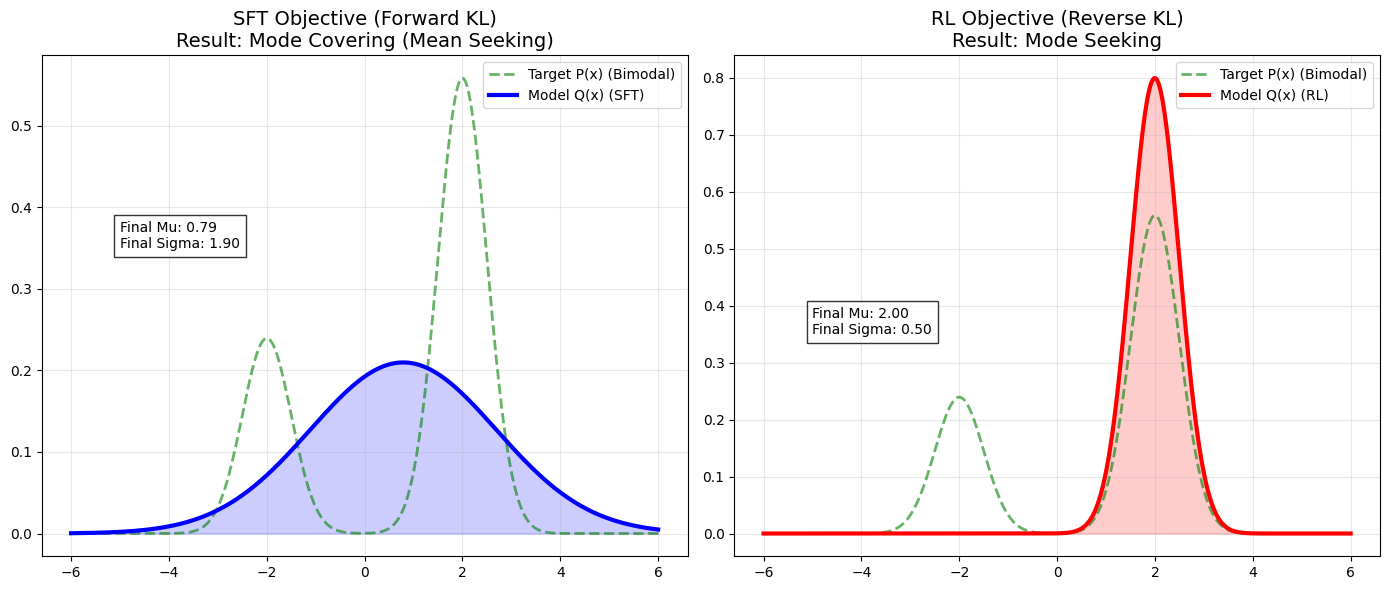

In [11]:
visualize_results()